# 02: Fleet exploratory analysis

1. What is the fleet: States, phases, capacity, coverage?
2. Where does it sit relative to the AS/NZS 4777.2 response thresholds? (as in, do we have enough measurement to check response?)
3. How many intervals survive to the Volt-VAr detection window?
4. **Does the fleet actually do Volt-VAr?** (the question that determines whether conformance scoring in 03_ is measuring a response or measuring noise.)
5. What is the `derating_active` flag?

In [36]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

_current = Path.cwd().resolve()
REPO_ROOT = next(
    (p for p in (_current, *_current.parents)
     if (p / "solar_edge").is_dir() and (p / "bms_sa_review").is_dir()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError(f"Could not locate the CICCADA repository root from {_current}")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd

from solar_edge.config import se_config as C
from solar_edge.lib import se_store, se_contract as contract, se_params
from solar_edge.lib import se_metadata as meta
from solar_edge.lib import se_queries as q
from solar_edge.lib import se_plots as plots

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

con = se_store.connect()
config = se_params.CONFIG
params = se_params.PARAMS
display(se_store.store_status(con)[["logical_name", "exists", "size_mb", "n_rows"]])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,logical_name,exists,size_mb,n_rows
0,se_interval,True,1469.9,86640968.0
1,se_interval_phase,False,NaN,NaN
2,se_site,True,0.1,1602.0
3,se_site_capacity,True,0.1,1600.0
4,bom_solar,False,NaN,NaN
5,se_structured,False,NaN,NaN
6,se_ghi_model,False,NaN,NaN
7,se_uncurtailedpv,False,NaN,NaN
8,se_conformance_voltvar,True,15.7,560087.0
9,se_conformance_voltwatt,True,7.0,560087.0


## 0. Data manifest

Note the `substitution` rows. 
They record what this delivery does **not** have nameplate capacity, a flexible-export flag, irradiance

Their absence is explicit rather than inferred from a default.

In [37]:
display(contract.manifest(config, params))

,section,setting,value
0,convention,active power: source convention,"generator (production magnitude, always >= 0)"
1,convention,active power: sign applied,+1 (no change)
2,convention,reactive sign: sites fitting,"213 as-delivered / 106 flipped / 1,271 neither"
3,convention,reactive power: source convention,AS DELIVERED -- majority of curve-following si...
4,convention,reactive power: sign applied,+1 (no change)
5,convention,target convention,generator (AS/NZS 4777.2 Fig 3.2; negative Q =...
6,convention,basis for the reactive sign,"fleet_orientation_fit over all 1,590 assessabl..."
7,convention,active power units,W -> kW
8,convention,reactive power units,var -> kvar (instantaneous; NOT multiplied by 12)
9,convention,raw timestamp frame,"per-site local civil time, INCLUDING daylight ..."


## 1. Build or refresh the site dimension

`s_99` is the 99th percentile of observed apparent power, ported from `build_s99_estimates.py`. 

It is an **empirical observation, not a manufacturer rating**.

A site that never reached its inverter limit will have an `s_99` below it, which biases the apparent-limit test toward finding symptoms. 

That is why the quantile is swept in sensitivity.

In [38]:
# Rebuilds only if se_site was built against a different store.
# Pass force=True to rebuild regardless.
meta.refresh_dimensions(con)

checks = meta.check_site_dimension(con)
display(checks)

meta.assert_checks(checks, label="D4")
display(meta.site_summary(con))

Site dimension is current with se_interval - no rebuild needed.


,check,expected,observed,pass,note
0,se_site is current with se_interval,not stale,current,True,se_site was built against a different store. R...
1,se_site has one row per site,"1,602","1,602",True,
2,site_alias unique,"1,602","1,602",True,
3,every site has a timezone,0 nulls,0,True,
4,every site has a postcode,0 nulls,0,True,
5,phase count is 1 or 3,0 others,0,True,"2-phase would mean a dropped phase, not a real..."
6,se_site_capacity covers every estimable site,"1,600","1,600",True,2 site(s) in the store have no interval with S...
7,s_99 positive everywhere,0 bad,0,True,
8,s_99 >= p_99 within tolerance,0 violations beyond 1% of p_99,0 (max gap 0.169%),True,"S = sqrt(P^2+Q^2) >= P exactly, but s_99 and p..."
9,geography attached (optional),"1,602 or 0 (pending shapefile)","1,602",True,D12 irradiance needs this; D5/D6 do not


D4: 10/10 checks passed


,state,n_sites,n_single_phase,n_three_phase,n_postcodes,median_s_99_kVA,median_p_99_kW,median_pct_days,n_night_anomaly
0,South Australia,574,408,166,153,5.01,5.00,100.0,6
1,New South Wales,570,468,102,202,5.75,5.73,100.0,8
2,Queensland,458,311,147,152,6.71,6.62,100.0,6


## 2. Fleet composition and coverage

,state,n_sites,single_phase,three_phase,pct_three_phase,n_postcodes,n_night_anomaly
0,South Australia,574,408,166,28.9,153,6
1,New South Wales,570,468,102,17.9,202,8
2,Queensland,458,311,147,32.1,152,6


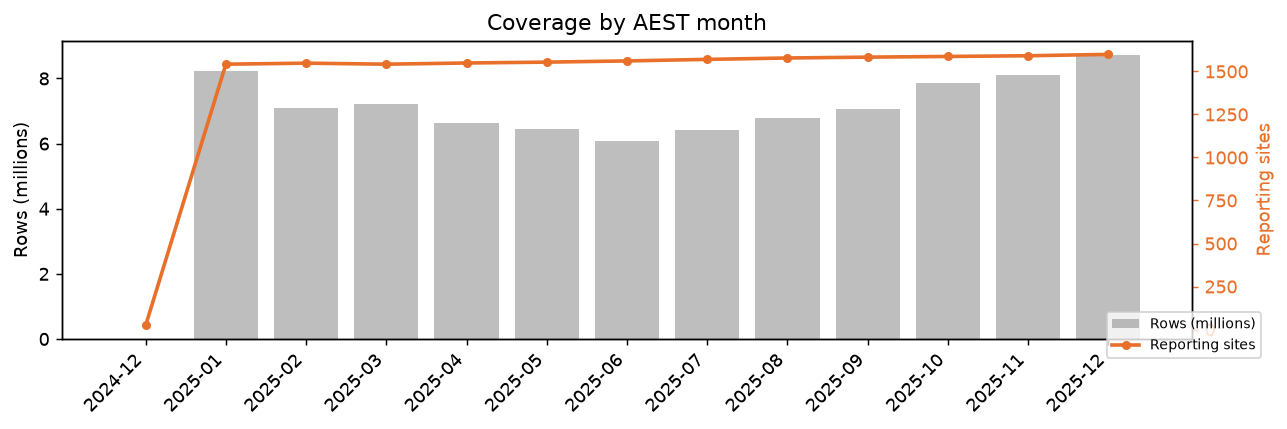

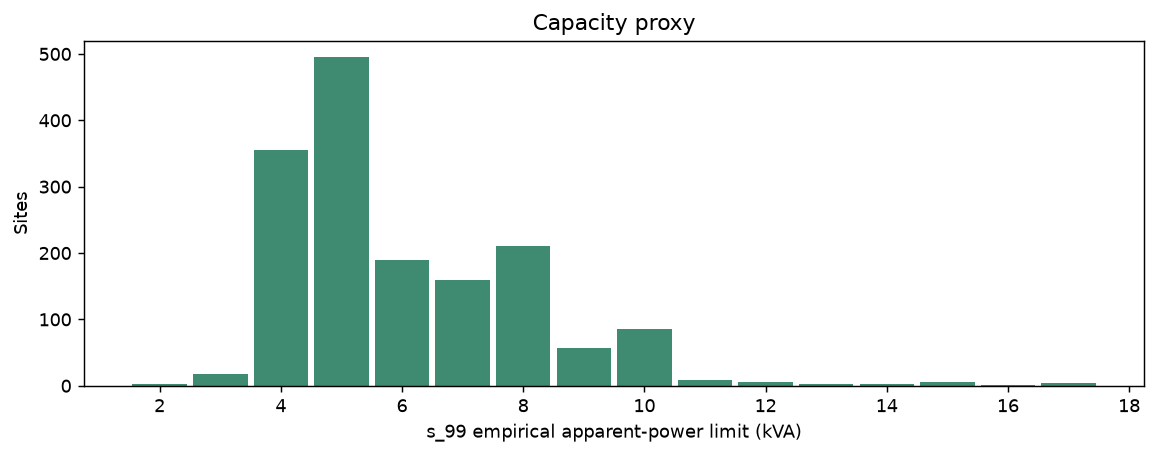

In [39]:
display(q.fleet_composition(con))

coverage = q.monthly_coverage(con)
display(plots.plot_monthly_coverage(coverage))

capacity = q.capacity_distribution(con)
display(plots.plot_capacity_distribution(capacity))

## 3. Timezone resolution check

The fleet diurnal profile in the AEST analysis frame. It must peak at hour 12. A double
hump or a smeared peak would mean the three states were pooled in mismatched frames.

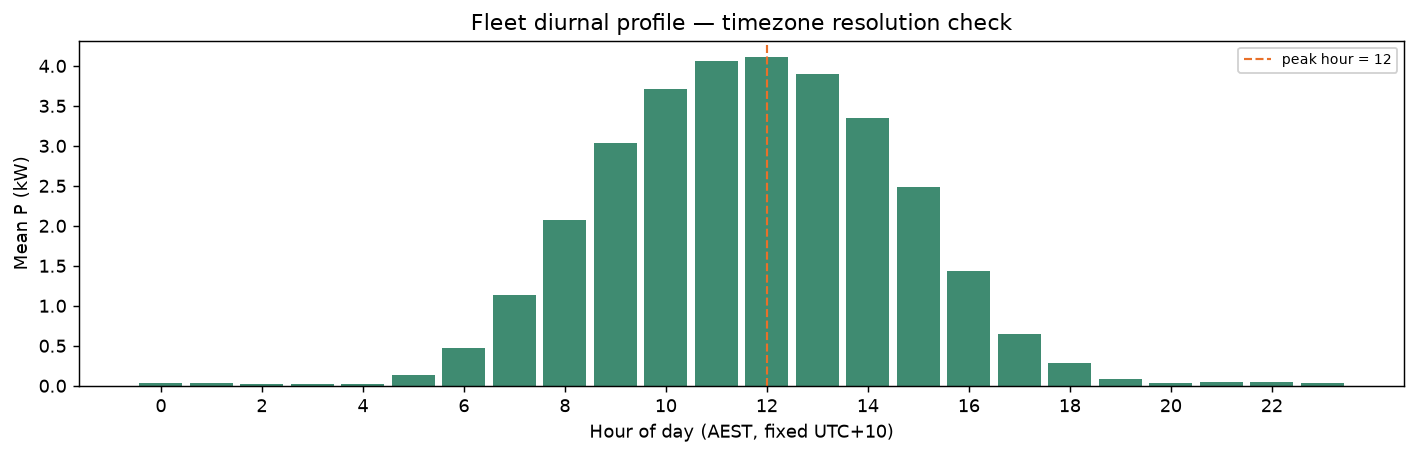

In [40]:
diurnal = q.diurnal_profile(con)
display(plots.plot_diurnal_profile(diurnal))

## 4. Where the fleet sits relative to the thresholds

This table sizes every downstream claim.

The **240–253 V band** is where Volt-VAr absorption is required and Volt-Watt has not yet engaged

The **253–258 V overlap** is where both respond at once. No disaggregation applied yet.

,band,band_order,n_intervals,n_sites,pct_of_intervals
0,below V1 (Volt-VAr supply region),0,1759,248,0.002
1,V1-V2 supply ramp (207-220 V),1,19201,283,0.023
2,V2-V3 deadband (220-240 V),2,24028719,1559,28.173
3,V3-VW1 Volt-VAr absorb only (240-253 V),3,60605192,1580,71.058
4,VW1-VVAR4 overlap (253-258 V),4,633112,558,0.742
5,above VVAR4 (258 V+),5,2339,126,0.003


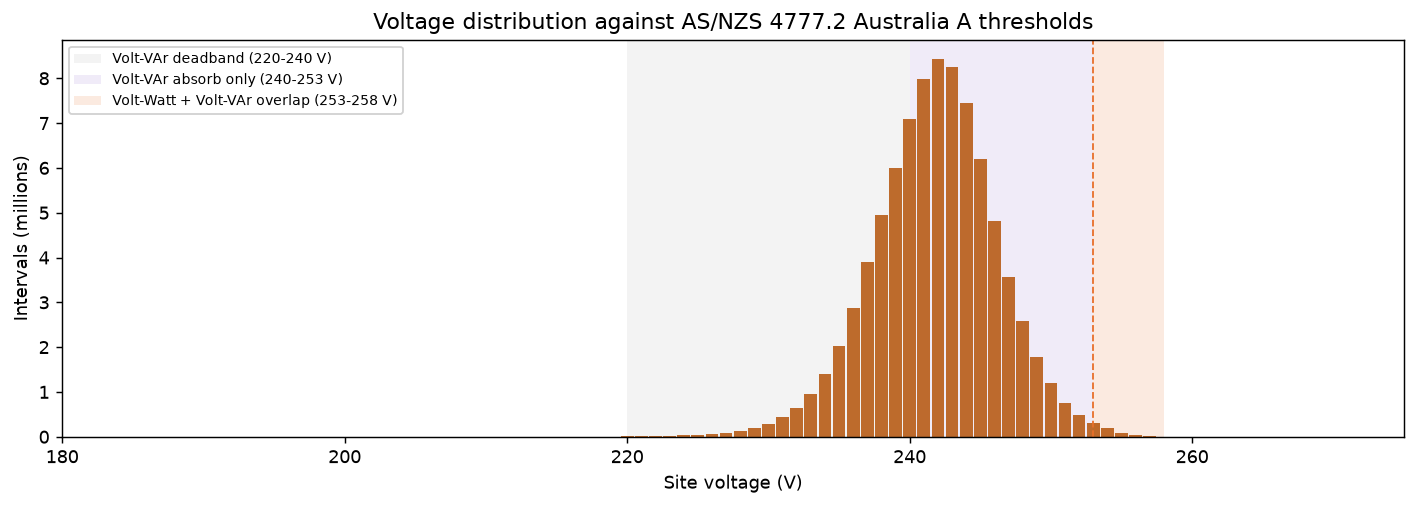

In [41]:
bands = q.voltage_band_occupancy(con, config)
display(bands)

vdist = q.voltage_distribution(con, config)
display(plots.plot_voltage_distribution(vdist))

## 5. Cohort funnel

Attrition from the whole store down to the detection window, in the same spirit as
`fetch_population_funnel` in the Solar Analytics work: never present a final count
without showing what it was drawn from.

In [42]:
display(q.cohort_funnel(con, config, params))

,stage,n_intervals,n_sites,pct_of_all
0,1. all stored intervals,86640968,1602,100.0000
1,2. cohort filters applied,85290322,1580,98.4411
2,3. + peak-solar window,20098673,1580,23.1977
3,4. + Volt-VAr voltage band,16165611,1579,18.6582
4,5. + absorbing reactive power (Q < 0),5676404,651,6.5516


## 6. Does the fleet do Volt-VAr?

Fleet-scale check:

In the generator convention a conforming inverter **absorbs** reactive power(Q < 0) above 240 V, so the median should slope **downward** with rising voltage.

In [43]:
signature = q.voltvar_signature(con, config)

for cohort in ("single-phase", "three-phase"):
    print(f"\n{'=' * 90}\n{cohort.upper()}\n{'=' * 90}")
    display(signature[signature.cohort == cohort].drop(columns="cohort")
            .reset_index(drop=True))


SINGLE-PHASE


,v_bin,n_intervals,n_sites,median_Q_kvar,mean_Q_kvar,mean_minus_median,p05_Q_kvar,p95_Q_kvar,pct_absorbing,mean_P_kW
0,205.0,121,17,0.1887,0.2319,0.0432,0.136,0.307,0.00,0.920
1,207.5,263,22,0.1844,0.2206,0.0362,0.132,0.317,0.00,0.869
2,210.0,555,45,0.1848,0.2283,0.0435,0.125,0.328,0.18,1.188
3,212.5,1254,75,0.1847,0.2379,0.0531,0.118,0.451,0.24,1.202
4,215.0,2789,118,0.1837,0.2369,0.0532,0.111,0.630,0.07,1.320
5,217.5,6270,191,0.1778,0.1990,0.0212,0.109,0.357,0.37,1.414
6,220.0,14054,262,0.1666,0.1785,0.0118,0.100,0.324,1.25,1.396
7,222.5,30739,381,0.1613,0.1690,0.0077,0.095,0.314,2.60,1.372
8,225.0,72163,530,0.1578,0.1606,0.0029,0.084,0.290,3.91,1.338
9,227.5,186274,699,0.1535,0.1511,-0.0024,-0.064,0.267,5.02,1.311



THREE-PHASE


,v_bin,n_intervals,n_sites,median_Q_kvar,mean_Q_kvar,mean_minus_median,p05_Q_kvar,p95_Q_kvar,pct_absorbing,mean_P_kW
0,215.0,137,16,-0.3325,-0.1182,0.2142,-1.340,1.397,71.53,1.117
1,217.5,370,30,-0.3007,-0.0595,0.2411,-0.568,0.853,68.11,1.206
2,220.0,898,51,-0.3002,-0.2038,0.0963,-0.507,0.471,82.07,1.391
3,222.5,3008,85,-0.3097,-0.2944,0.0154,-0.508,0.275,93.75,1.500
4,225.0,9203,119,-0.3097,-0.3077,0.0020,-0.500,-0.165,96.01,1.606
5,227.5,30982,190,-0.3006,-0.3111,-0.0105,-0.489,-0.181,97.74,1.717
6,230.0,117520,254,-0.2920,-0.3124,-0.0204,-0.490,-0.178,98.48,1.840
7,232.5,398511,326,-0.2880,-0.3201,-0.0320,-0.506,-0.172,98.80,2.073
8,235.0,1292380,375,-0.2899,-0.3459,-0.0561,-0.572,-0.176,99.09,2.394
9,237.5,3085516,402,-0.2830,-0.3470,-0.0640,-0.544,-0.183,99.28,2.879


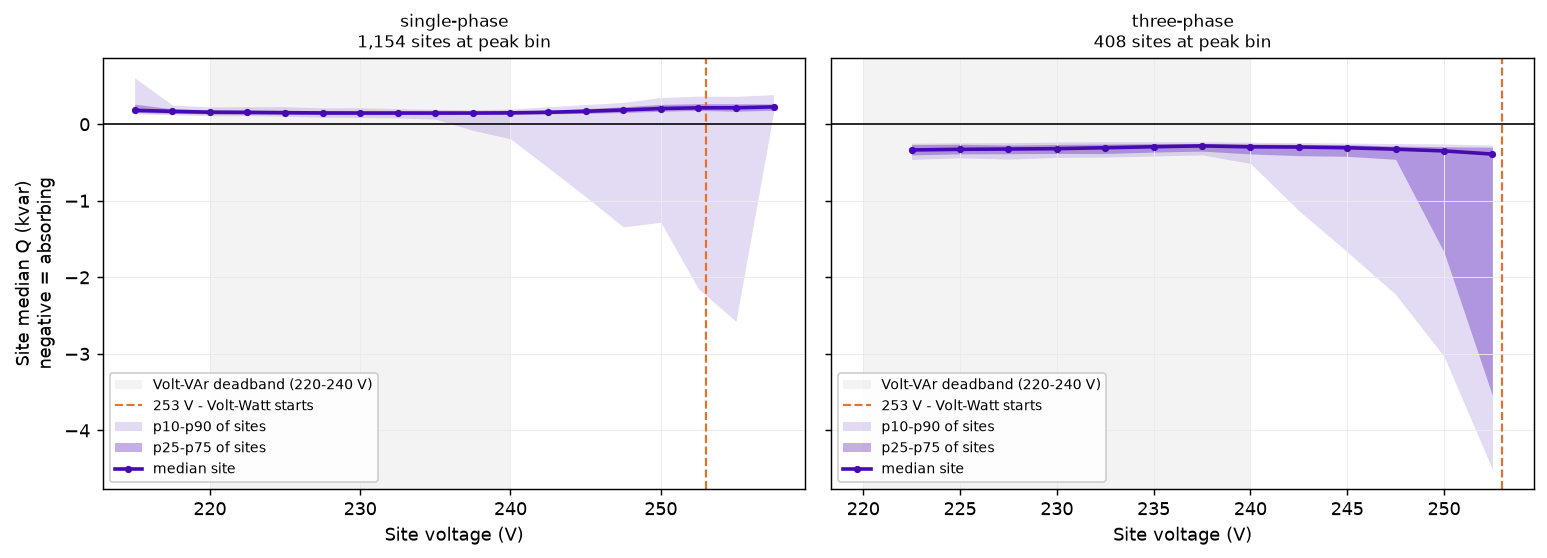

,cohort,v_bin,n_sites,p10,p25,p50,p75,p90,pct_sites_absorbing
14,single-phase,250.0,683,-1.2814,0.1700,0.2048,0.2590,0.3486,12.0
15,single-phase,252.5,351,-2.1499,0.1799,0.2142,0.2686,0.3664,11.4
16,single-phase,255.0,129,-2.5764,0.1697,0.2144,0.2673,0.3640,13.2
17,single-phase,257.5,23,0.1499,0.1825,0.2270,0.2654,0.3865,4.3
27,three-phase,245.0,352,-1.6675,-0.4193,-0.3073,-0.2679,-0.2461,98.6
28,three-phase,247.5,253,-2.2232,-0.4585,-0.3262,-0.2850,-0.2522,98.0
29,three-phase,250.0,121,-3.0330,-1.6698,-0.3486,-0.2940,-0.2580,95.9
30,three-phase,252.5,29,-4.5066,-3.5420,-0.3900,-0.3010,-0.2729,100.0


In [44]:
spread = q.voltvar_site_spread(con, config)
display(plots.plot_voltvar_spread(spread))
display(spread.groupby("cohort").tail(4))

### How many inverters actually respond?

One number per site: how far its median Q moves from the deadband to the upper Volt-VAr
ramp. In the generator convention a conforming inverter **absorbs more** as voltage
rises, so responders sit left of zero (shaded).

Everything piled at zero is a site doing nothing. This is the direct answer to *"how much
of my fleet does Volt-VAr"*, which the pooled median cannot give.

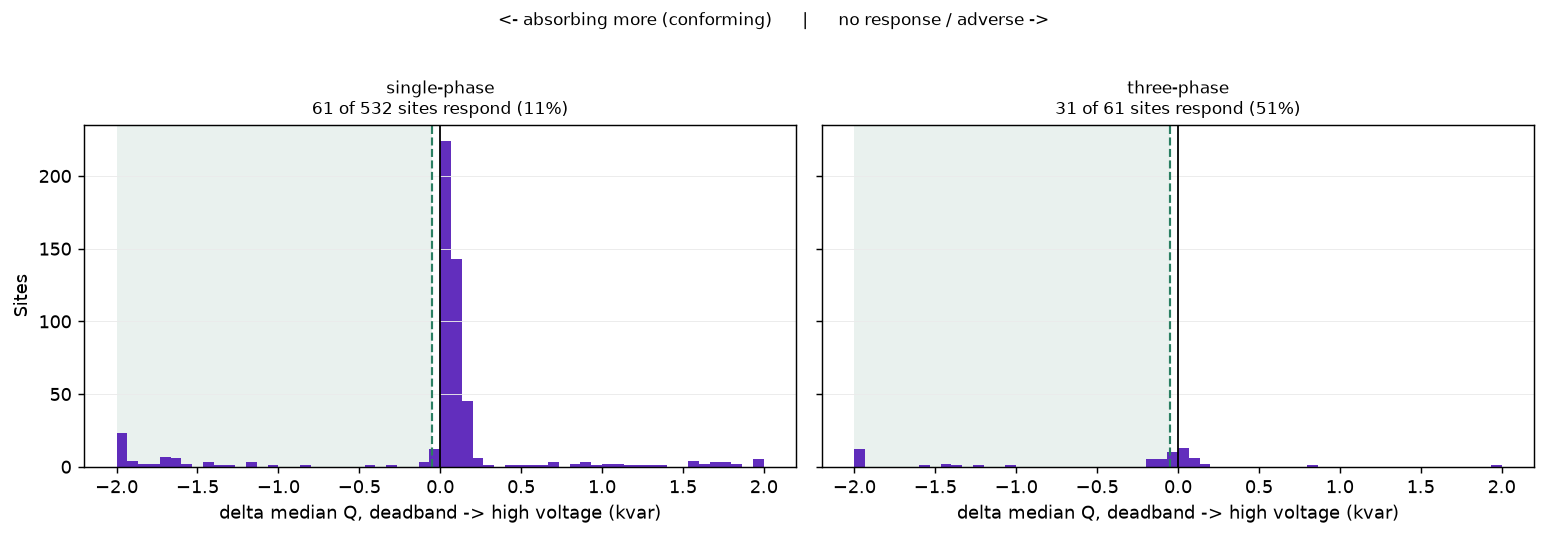

 single-phase:   61 of  532 sites respond (11.5%)  |  median delta +0.060 kvar
  three-phase:   31 of   61 sites respond (50.8%)  |  median delta -0.053 kvar


In [45]:
response = q.voltvar_site_response(con, config)
display(plots.plot_site_response_histogram(response))

for cohort, g in response.groupby("cohort"):
    n_resp = int((g.delta_q_kvar < -0.05).sum())
    print(f"{cohort:>13}: {n_resp:>4} of {len(g):>4} sites respond "
          f"({100 * n_resp / len(g):.1f}%)  |  "
          f"median delta {g.delta_q_kvar.median():+.3f} kvar")

response.to_csv(C.ARTEFACT_DIR / "voltvar_site_response.csv", index=False)

### 6a. Magnitude, and the two ways of normalising it

**median |Q|** — the *numerator*. How much reactive power the inverter moves, regardless
of direction. Rising with voltage means it is doing more.

**median power factor** — cos(φ) = P / S = P / √(P² + Q²). This is the correct
normalised quantity, and it is bounded in [0, 1]: 1.000 means the inverter is moving no
reactive power at all.

**median tan(φ) = Q/P** — reported in the table as `med_tan_phi`. This is *not* power
factor. An earlier version of this notebook called it that, which was wrong. It is also
confounded, and that confound is worth seeing.

**Why tan(φ) falls for single-phase, even though the response strengthens.** Site voltage
rises *because* export rises, so between 235 V and 250 V:

| | 235 V | 250 V | change |
|---|---|---|---|
| median \|Q\| | 0.154 kvar | 0.229 kvar | **+49%** |
| median P | 1.43 kW | 4.58 kW | **+219%** |
| tan(φ) = Q/P | 0.105 | 0.046 | −56% |

|Q| is *increasing*. tan(φ) falls only because P more than triples underneath it. The
denominator is doing the work.

Power factor is subject to the same arithmetic, but it does not invert the reading: it
moves 0.9934 → 0.9987 over the same span, i.e. **towards unity**, correctly saying the
reactive contribution is small relative to a rapidly growing P. It never suggests the
inverter stopped responding.

The middle panel below shows P explicitly so the confound is visible rather than
inferred. **Read the left panel for the response.**

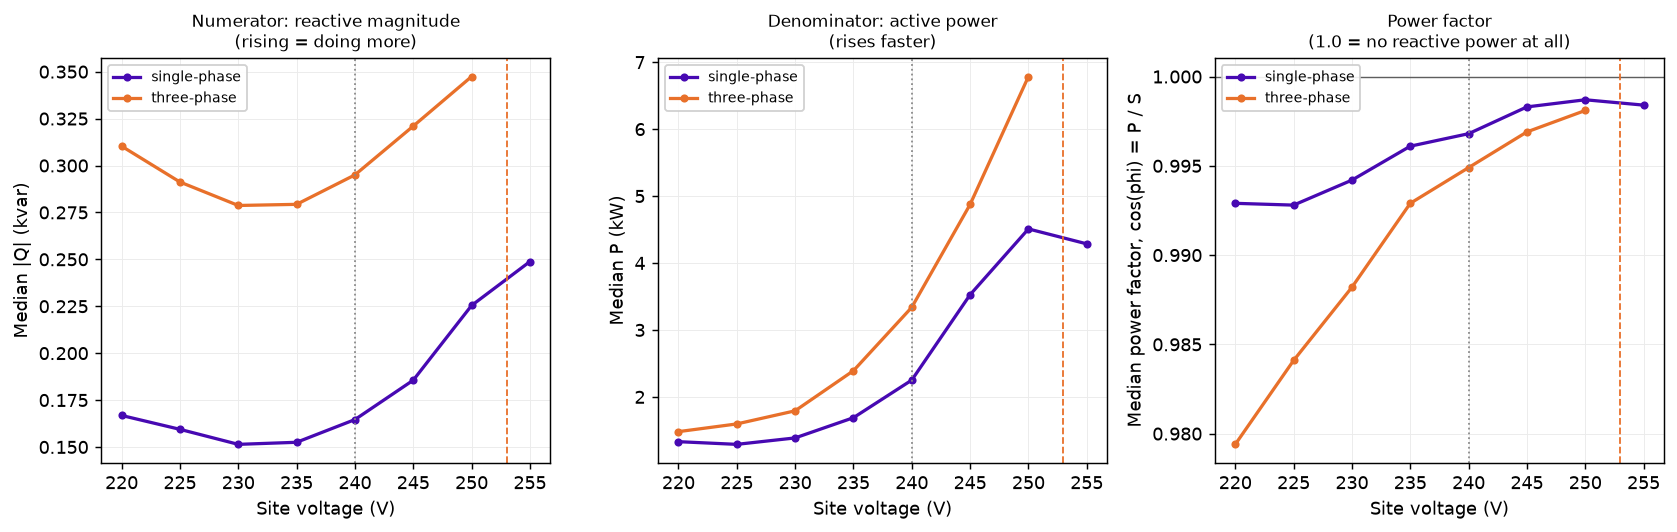

,cohort,v_bin,n_intervals,med_P_kW,med_Q_kvar,med_abs_Q_kvar,med_tan_phi,med_power_factor
0,single-phase,220.0,31876,1.331,0.1655,0.1668,0.1169,0.9929
1,single-phase,225.0,183252,1.291,0.1572,0.1594,0.1149,0.9928
2,single-phase,230.0,1432444,1.387,0.1480,0.1514,0.1003,0.9942
3,single-phase,235.0,8161784,1.689,0.1483,0.1525,0.0801,0.9961
4,single-phase,240.0,20313892,2.251,0.1519,0.1646,0.0633,0.9968
5,single-phase,245.0,12859229,3.526,0.1699,0.1856,0.0499,0.9983
6,single-phase,250.0,2615113,4.509,0.2053,0.2254,0.0467,0.9987
7,single-phase,255.0,134730,4.286,0.2159,0.2488,0.0477,0.9984
8,three-phase,220.0,2829,1.481,-0.2962,0.3103,-0.1845,0.9794
9,three-phase,225.0,29989,1.596,-0.2890,0.2912,-0.1746,0.9841


Median power factor by cohort:


cohort
single-phase    0.99645
three-phase     0.99290
Name: med_power_factor, dtype: float64

In [46]:
character = q.reactive_character(con, config)
display(plots.plot_reactive_character(character))
display(character)

print("Median power factor by cohort:")
display(character.groupby("cohort").med_power_factor.median())

### 6b. Single-phase versus three-phase sign check

In [47]:
display(q.phase_cohort_comparison(con, config))

,cohort,v_band,n_intervals,n_sites,median_Q_kvar,pct_absorbing
0,single-phase,high (>250 V),2764932,851,0.2054,11.50
1,single-phase,low (<235 V),2224089,1025,0.1479,6.64
2,single-phase,mid (235-250 V),46316431,1165,0.1541,12.02
3,three-phase,high (>250 V),228049,179,-0.3460,99.30
4,three-phase,low (<235 V),560739,333,-0.2901,98.55
5,three-phase,mid (235-250 V),17942712,415,-0.3000,98.82


## 7. The `derating_active` flag

If it is voltage-driven it corroborates the Volt-Watt / Volt-VAr analysis.

A flat baseline at ordinary voltages is something else.

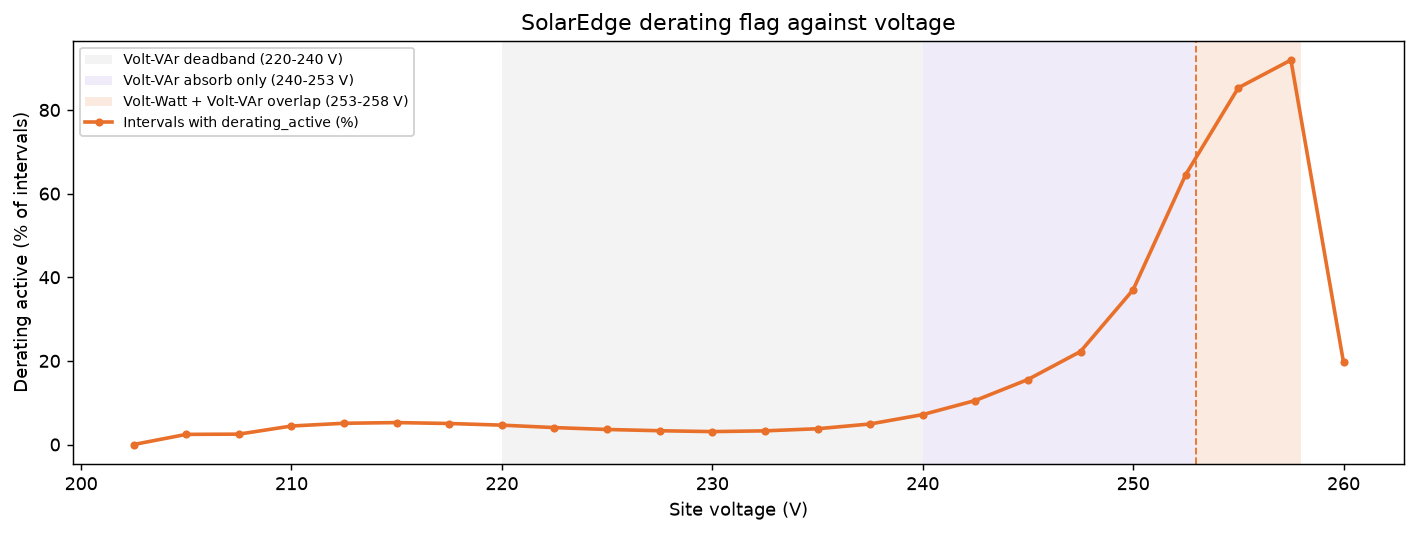

,v_bin,n_intervals,n_derating,pct_derating,mean_P_kW,mean_P_derating
0,202.5,128,0,0.000,0.463,NaN
1,205.0,206,5,2.427,0.569,1.913
2,207.5,443,11,2.483,0.538,1.196
3,210.0,994,44,4.427,0.718,2.970
4,212.5,2164,110,5.083,0.825,2.967
5,215.0,4804,252,5.246,0.817,2.909
6,217.5,10741,540,5.027,0.887,3.108
7,220.0,24484,1134,4.632,0.872,3.089
8,222.5,55744,2258,4.051,0.858,3.046
9,225.0,136563,4913,3.598,0.835,2.870


In [48]:
derating = q.derating_by_voltage(con, config)
display(plots.plot_derating_by_voltage(derating))
display(derating)

In [49]:
display(q.derating_by_cohort(con, config))

,cohort,generation_level,n_intervals,n_derating,pct_derating
0,single-phase,at or above 50% of p_99,21538776,6477215,30.072
1,single-phase,below 50% of p_99,32452147,2076390,6.398
2,single-phase,not generating,7535599,50230,0.667
3,three-phase,at or above 50% of p_99,7562455,619165,8.187
4,three-phase,below 50% of p_99,11947986,30481,0.255
5,three-phase,not generating,4253359,6126,0.144


## 8. Sensitivity of the cohort to its own definition

In [50]:
variants = {
    "default": config,
    "voltage = mean of phases": config.with_changes(voltage_aggregation="mean"),
    "single-phase only": config.with_changes(phase_cohort="single"),
    "three-phase only": config.with_changes(phase_cohort="three"),
    "exclude derating intervals": config.with_changes(derating_selection="exclude"),
    "include night-anomaly sites": config.with_changes(night_anomaly_selection="include"),
    "sites with >= 300 days": config.with_changes(min_days_observed=300),
}

rows = []
for label, variant in variants.items():
    funnel = q.cohort_funnel(con, variant, params)
    band = funnel.iloc[3]
    rows.append({
        "variant": label,
        "cohort_intervals": int(funnel.iloc[1].n_intervals),
        "in_voltvar_window": int(band.n_intervals),
        "sites_in_window": int(band.n_sites),
    })
display(pd.DataFrame(rows))

,variant,cohort_intervals,in_voltvar_window,sites_in_window
0,default,85290322,16165611,1579
1,voltage = mean of phases,85290322,16165611,1579
2,single-phase only,61526522,11922806,1165
3,three-phase only,23763800,4242805,414
4,exclude derating intervals,76030715,11901752,1579
5,include night-anomaly sites,86640785,16381169,1599
6,sites with >= 300 days,82908898,15697838,1500


## 9. Data-quality report (D7)

Every known issue quantified against an explicit threshold, run against the **built store** .

- **`ok` / `WARN`**: measurable defects with a threshold. These can pass or fail.
- **`STRUCTURAL`**: Properties of the delivery that cannot be fixed and must be carried   as stated limitations: no nameplate, no irradiance, a derating flag with no explicitzero, sparse overnight coverage, timestamps off a common grid.

In [51]:
from solar_edge.lib import se_diagnostics as diag

quality = diag.data_quality_report(con)
display(quality)

n_warn = int((quality.status == "WARN").sum())
n_struct = int((quality.status == "STRUCTURAL").sum())
print(f"{n_warn} warnings, {n_struct} structural limitations")

quality.to_csv(C.ARTEFACT_DIR / "data_quality_report.csv", index=False)
print(f"Written to {C.ARTEFACT_DIR / 'data_quality_report.csv'}")

,issue,measure,value,threshold,status,note
0,voltage missing,% intervals with NULL V_max,0.0000%,< 1%,ok,
1,voltage zero,% intervals with V_max <= 0,0.0000%,< 0.1%,ok,"zeros are inverter-off states, not measurement..."
2,voltage implausibly high,% intervals with V_max > 270 V,0.0000%,< 0.01%,ok,
3,voltage implausibly low,% intervals with 0 < V_max < 180 V,0.0003%,< 0.1%,ok,
4,active power missing,% intervals with NULL P_kW,0.0000%,< 1%,ok,
5,active power negative,% intervals with P_kW < 0,0.0000%,0%,ok,SolarEdge reports production magnitude; any ne...
6,reactive power missing,% intervals with NULL Q_kvar,0.0000%,< 5%,ok,
7,frequency out of range,% intervals outside 45-55 Hz,0.0006%,< 0.01%,ok,
8,no phase reporting,% intervals with zero phases,0.0000%,< 0.1%,ok,
9,night-time generation (mis-framed timestamps),% intervals with P > 0.5 kW at 21:00-04:00 AEST,0.0255% across 20 sites,< 0.1%,ok,excluded by default via night_anomaly_selectio...


0 warnings, 5 structural limitations
Written to C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\solar_edge\artefacts\data_quality_report.csv
